# SBI posterior parameter evaluation

Set `RUN_NAME` in the cell below. Everything else is auto-detected from `run_info.json`.

**Point estimate comparison**: posterior mean vs GT — MAE, Median AE, MAPE  
**Posterior-specific**: 90% credible interval coverage per parameter

In [ ]:
RUN_NAME            = 'exp_cnn4e64_maf5_freeze-maf'
BATCH_IDX           = 0
N_POSTERIOR_SAMPLES = 1000

In [ ]:
import json, sys, importlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

ROOT = Path(globals()['_dh'][0])
sys.path.insert(0, str(ROOT))

from dataset import CVDataset, ReducedCVDataset, PARAM_KEYS, PARAM_KEYS_INFER, load_stats

POSTERIOR_PATH = ROOT / f'outputs/{RUN_NAME}/posterior.pt'
STATS_PATH     = ROOT / 'norm_stats.json'
DATA_DIR       = Path('/media/pulsar/SimData/hdf5/cv8/simset_10M_cv8Eed_20260314/test')
MANIFEST       = DATA_DIR.parent / 'manifest_test.json'
BATCH_SIZE     = 256
device         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

run_info = json.load(open(POSTERIOR_PATH.parent / 'run_info.json'))
emb_type = run_info['embedding']['type']

_CONFIG = {
    'WaveformEmbedding':            (CVDataset,        PARAM_KEYS,       'train_sbi', (5, 5)),
    'ReducedWaveformEmbedding':     (ReducedCVDataset, PARAM_KEYS_INFER, 'train_sbi', (6, 4)),
    'TransformerWaveformEmbedding': (ReducedCVDataset, PARAM_KEYS_INFER, 'train_sbi', (6, 4)),
    'ReducedAutoencoderEncoder':    (ReducedCVDataset, PARAM_KEYS_INFER, 'models',    (6, 4)),
}
dataset_cls, PARAM_KEYS_USE, emb_module, (scatter_ncols, scatter_nrows) = _CONFIG[emb_type]

# Inject into __main__ so torch.load can unpickle — posteriors were saved when
# train_sbi.py ran as __main__, so pickle stored the class as __main__.<ClassName>
globals()[emb_type] = getattr(importlib.import_module(emb_module), emb_type)

print(f'Run:       {RUN_NAME}')
print(f'Embedding: {emb_type}')
print(f'Params:    {len(PARAM_KEYS_USE)}  Scatter grid: {scatter_nrows}×{scatter_ncols}')
print(f'Device:    {device}')

## Load posterior and test data

In [32]:
try:
    posterior = torch.load(POSTERIOR_PATH, map_location=device, weights_only=False)
except (torch.cuda.OutOfMemoryError, RuntimeError):
    print("GPU OOM — falling back to CPU")
    device = torch.device('cpu')
    torch.cuda.empty_cache()
    posterior = torch.load(POSTERIOR_PATH, map_location='cpu', weights_only=False)

print('Posterior loaded:', type(posterior).__name__, f'  device: {device}')

stats    = load_stats(STATS_PATH)
manifest = json.load(open(MANIFEST))

start   = BATCH_IDX * BATCH_SIZE
end     = start + BATCH_SIZE
entries = manifest['index'][start:end]
print(f'Test batch {BATCH_IDX}: sims {start}–{end - 1}  ({len(entries)} entries)')

ds     = dataset_cls(str(DATA_DIR), entries, stats)
loader = DataLoader(ds, batch_size=BATCH_SIZE, num_workers=0)

all_theta, all_x = [], []
for theta_b, x_b in loader:
    all_theta.append(theta_b)
    all_x.append(x_b)
ds.close()

theta_gt = torch.cat(all_theta)
x_test   = torch.cat(all_x)
print(f'GT params: {theta_gt.shape}  observations: {x_test.shape}')

GPU OOM — falling back to CPU
Posterior loaded: DirectPosterior   device: cpu
Test batch 0: sims 0–255  (256 entries)
GT params: torch.Size([256, 25])  observations: torch.Size([256, 5628])


## Embedding diagnostics

In [33]:
emb_net = posterior.posterior_estimator.embedding_net

with torch.no_grad():
    emb_out = emb_net(x_test[:64].to(device))
print(f'Embedding output shape: {emb_out.shape}')
print(f'Per-dim std  min/mean/max: '
      f'{emb_out.std(0).min():.4f} / {emb_out.std(0).mean():.4f} / {emb_out.std(0).max():.4f}')
print(f'Overall mean: {emb_out.mean():.4f}  std: {emb_out.std():.4f}')

train_data_dir = str(DATA_DIR.parent / 'train')
train_manifest = json.load(open(MANIFEST.parent / 'manifest_train.json'))
ds_tr = dataset_cls(train_data_dir, train_manifest['index'][:1], stats)
theta_tr, x_tr = ds_tr[0]
ds_tr.close()

with torch.no_grad():
    samples_tr = posterior.sample((500,), x=x_tr.to(device), show_progress_bars=False)
post_mean_tr = samples_tr.mean(0).cpu()

print(f"\nTraining obs sanity check:")
print(f"  {'param':<14} {'GT':>10} {'post mean':>12} {'err%':>8}")
for i, name in enumerate(PARAM_KEYS_USE):
    err = abs(post_mean_tr[i].item() - theta_tr[i].item()) / (abs(theta_tr[i].item()) + 1e-9) * 100
    print(f"  {name:<14} {theta_tr[i].item():>10.4f} {post_mean_tr[i].item():>12.4f} {err:>7.1f}%")

Embedding output shape: torch.Size([64, 64])
Per-dim std  min/mean/max: 0.6243 / 1.3464 / 2.1958
Overall mean: -0.0498  std: 1.5122

Training obs sanity check:
  param                  GT    post mean     err%
  AVD              278.7117     253.6076     9.0%
  Bla                0.0598       0.0498    16.8%
  Blv                0.0211       0.0274    30.0%
  Bra                0.0664       0.0692     4.2%
  Brv                0.0511       0.0440    13.9%
  Cas                0.7144       0.7218     1.0%
  Cvp                5.2836       5.2302     1.0%
  Cvs               50.4620      50.2966     0.3%
  Eap                3.0521       3.1516     3.3%
  Eedref_la          2.0508       1.4221    30.7%
  Eedref_lv          0.7180       1.2904    79.7%
  Eedref_ra          0.3933       0.4555    15.8%
  Eedref_rv          0.5214       0.3754    28.0%
  Emax_LA            0.5651       0.6025     6.6%
  Emax_LV            4.9090       4.8035     2.1%
  Emax_RA            0.1293       0.1470

## Sample posterior for each test observation

In [34]:
all_means, all_q05, all_q95 = [], [], []

for i, x_o in enumerate(x_test):
    samples = posterior.sample((N_POSTERIOR_SAMPLES,), x=x_o.to(device), show_progress_bars=False)
    all_means.append(samples.mean(dim=0).cpu())
    all_q05.append(samples.quantile(0.05, dim=0).cpu())
    all_q95.append(samples.quantile(0.95, dim=0).cpu())
    if (i + 1) % 50 == 0:
        print(f'  {i + 1}/{len(x_test)} done')

pred_mean = torch.stack(all_means).numpy()
q05       = torch.stack(all_q05).numpy()
q95       = torch.stack(all_q95).numpy()
gt_phys   = theta_gt.numpy()
print(f'Posterior mean shape: {pred_mean.shape}')

                    accepted. It may take a long time to collect the remaining
                    913 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.


  50/256 done
  100/256 done
  150/256 done
  200/256 done
  250/256 done
Posterior mean shape: (256, 25)


## Point-estimate metrics

In [35]:
abs_err = np.abs(pred_mean - gt_phys)
ch_mae  = abs_err.mean(axis=0)
ch_med  = np.median(abs_err, axis=0)
ch_mape = (abs_err / (np.abs(gt_phys) + 1e-9) * 100).mean(axis=0)

print(f"{'Parameter':<14} {'MAE':>12} {'Median AE':>12} {'MAPE (%)':>10}")
print('-' * 52)
for i, name in enumerate(PARAM_KEYS_USE):
    print(f'{name:<14} {ch_mae[i]:>12.4f} {ch_med[i]:>12.4f} {ch_mape[i]:>10.2f}%')

print(f'\nOverall  MAE (mean): {ch_mae.mean():.4f}  MAPE: {ch_mape.mean():.2f}%')

Parameter               MAE    Median AE   MAPE (%)
----------------------------------------------------
AVD                 19.3018      11.1541      12.33%
Bla                  0.0162       0.0143      28.95%
Blv                  0.0039       0.0031      11.16%
Bra                  0.0149       0.0147      29.09%
Brv                  0.0081       0.0077      23.28%
Cas                  0.0091       0.0071       0.88%
Cvp                  0.0413       0.0289       1.14%
Cvs                  0.3940       0.3131       0.65%
Eap                  0.0313       0.0118       2.53%
Eedref_la            0.2678       0.1246      30.70%
Eedref_lv            0.1251       0.0678      17.54%
Eedref_ra            0.1190       0.0739      29.79%
Eedref_rv            0.1557       0.1037      40.13%
Emax_LA              0.0244       0.0159       7.70%
Emax_LV              0.0178       0.0096       0.76%
Emax_RA              0.0337       0.0177      10.79%
Emax_RV              0.0152       0.0097       

In [36]:
post_mean_std = pred_mean.std(axis=0)
prior_range   = np.array([
    manifest['config']['pvar_high'][k] - manifest['config']['pvar_low'][k]
    for k in PARAM_KEYS_USE
])
variation_pct = post_mean_std / prior_range * 100

print(f"{'param':<14} {'post-mean std':>14} {'prior range':>12} {'variation %':>12}")
print('-' * 55)
for i, name in enumerate(PARAM_KEYS_USE):
    print(f"{name:<14} {post_mean_std[i]:>14.4f} {prior_range[i]:>12.4f} {variation_pct[i]:>11.1f}%")

print(f"\nMean variation across params: {variation_pct.mean():.1f}% of prior range")

param           post-mean std  prior range  variation %
-------------------------------------------------------
AVD                   61.2282     240.0000        25.5%
Bla                    0.0152       0.0900        16.9%
Blv                    0.0095       0.0400        23.8%
Bra                    0.0095       0.0700        13.6%
Brv                    0.0055       0.0400        13.7%
Cas                    0.7192       2.4500        29.4%
Cvp                    2.3753       8.0000        29.7%
Cvs                   25.3545      90.0000        28.2%
Eap                    1.4673       4.9700        29.5%
Eedref_la              0.6050       2.4000        25.2%
Eedref_lv              0.4913       1.9200        25.6%
Eedref_ra              0.4034       1.4700        27.4%
Eedref_rv              0.3694       1.4700        25.1%
Emax_LA                0.2536       0.9000        28.2%
Emax_LV                1.2476       4.5000        27.7%
Emax_RA                0.1962       0.7000      

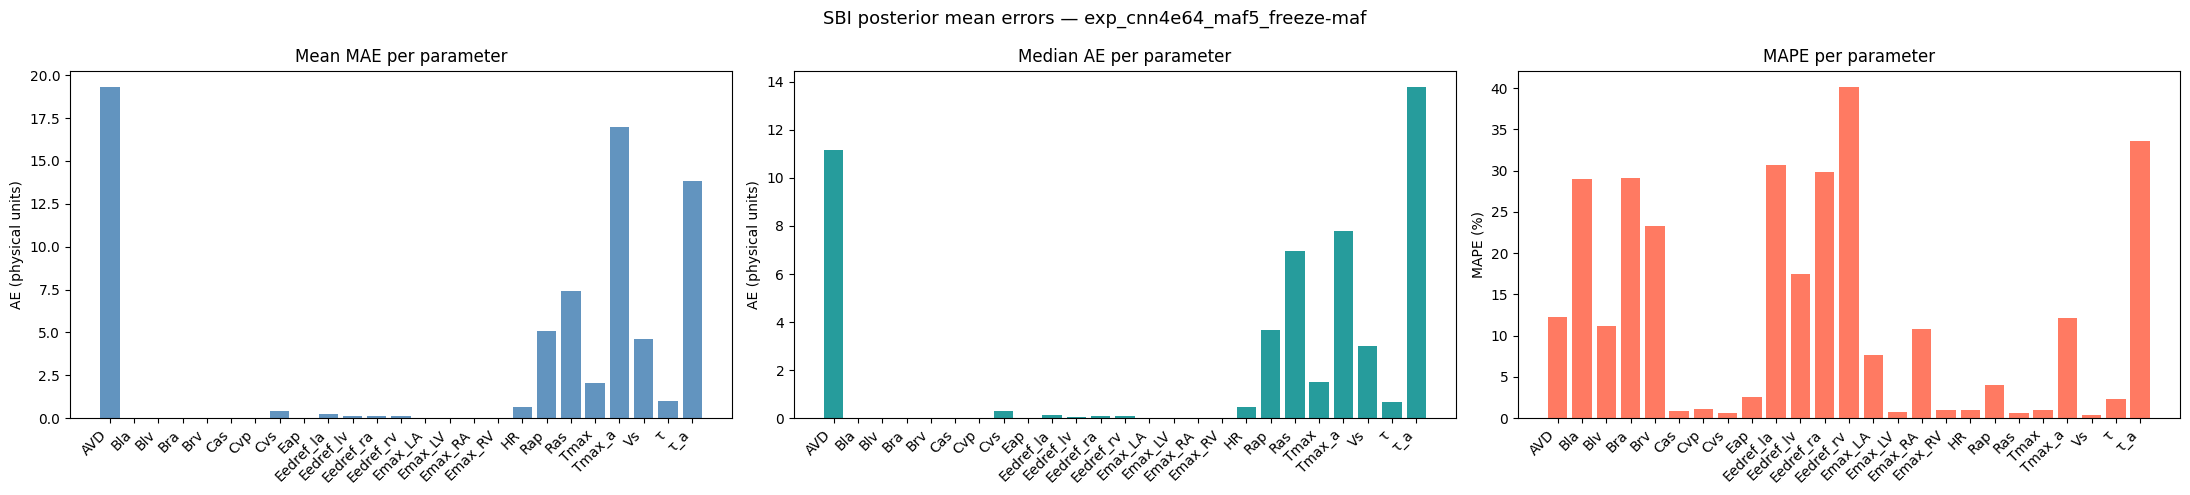

In [37]:
x_pos = np.arange(len(PARAM_KEYS_USE))
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

axes[0].bar(x_pos, ch_mae,  color='steelblue', alpha=0.85)
axes[1].bar(x_pos, ch_med,  color='darkcyan',  alpha=0.85)
axes[2].bar(x_pos, ch_mape, color='tomato',    alpha=0.85)

for ax, title, ylabel in zip(axes,
    ['Mean MAE per parameter', 'Median AE per parameter', 'MAPE per parameter'],
    ['AE (physical units)', 'AE (physical units)', 'MAPE (%)']):
    ax.set_xticks(x_pos)
    ax.set_xticklabels(PARAM_KEYS_USE, rotation=45, ha='right')
    ax.set_title(title)
    ax.set_ylabel(ylabel)

fig.suptitle(f'SBI posterior mean errors — {RUN_NAME}', fontsize=13)
plt.tight_layout()
plt.show()

## Predicted vs GT scatter

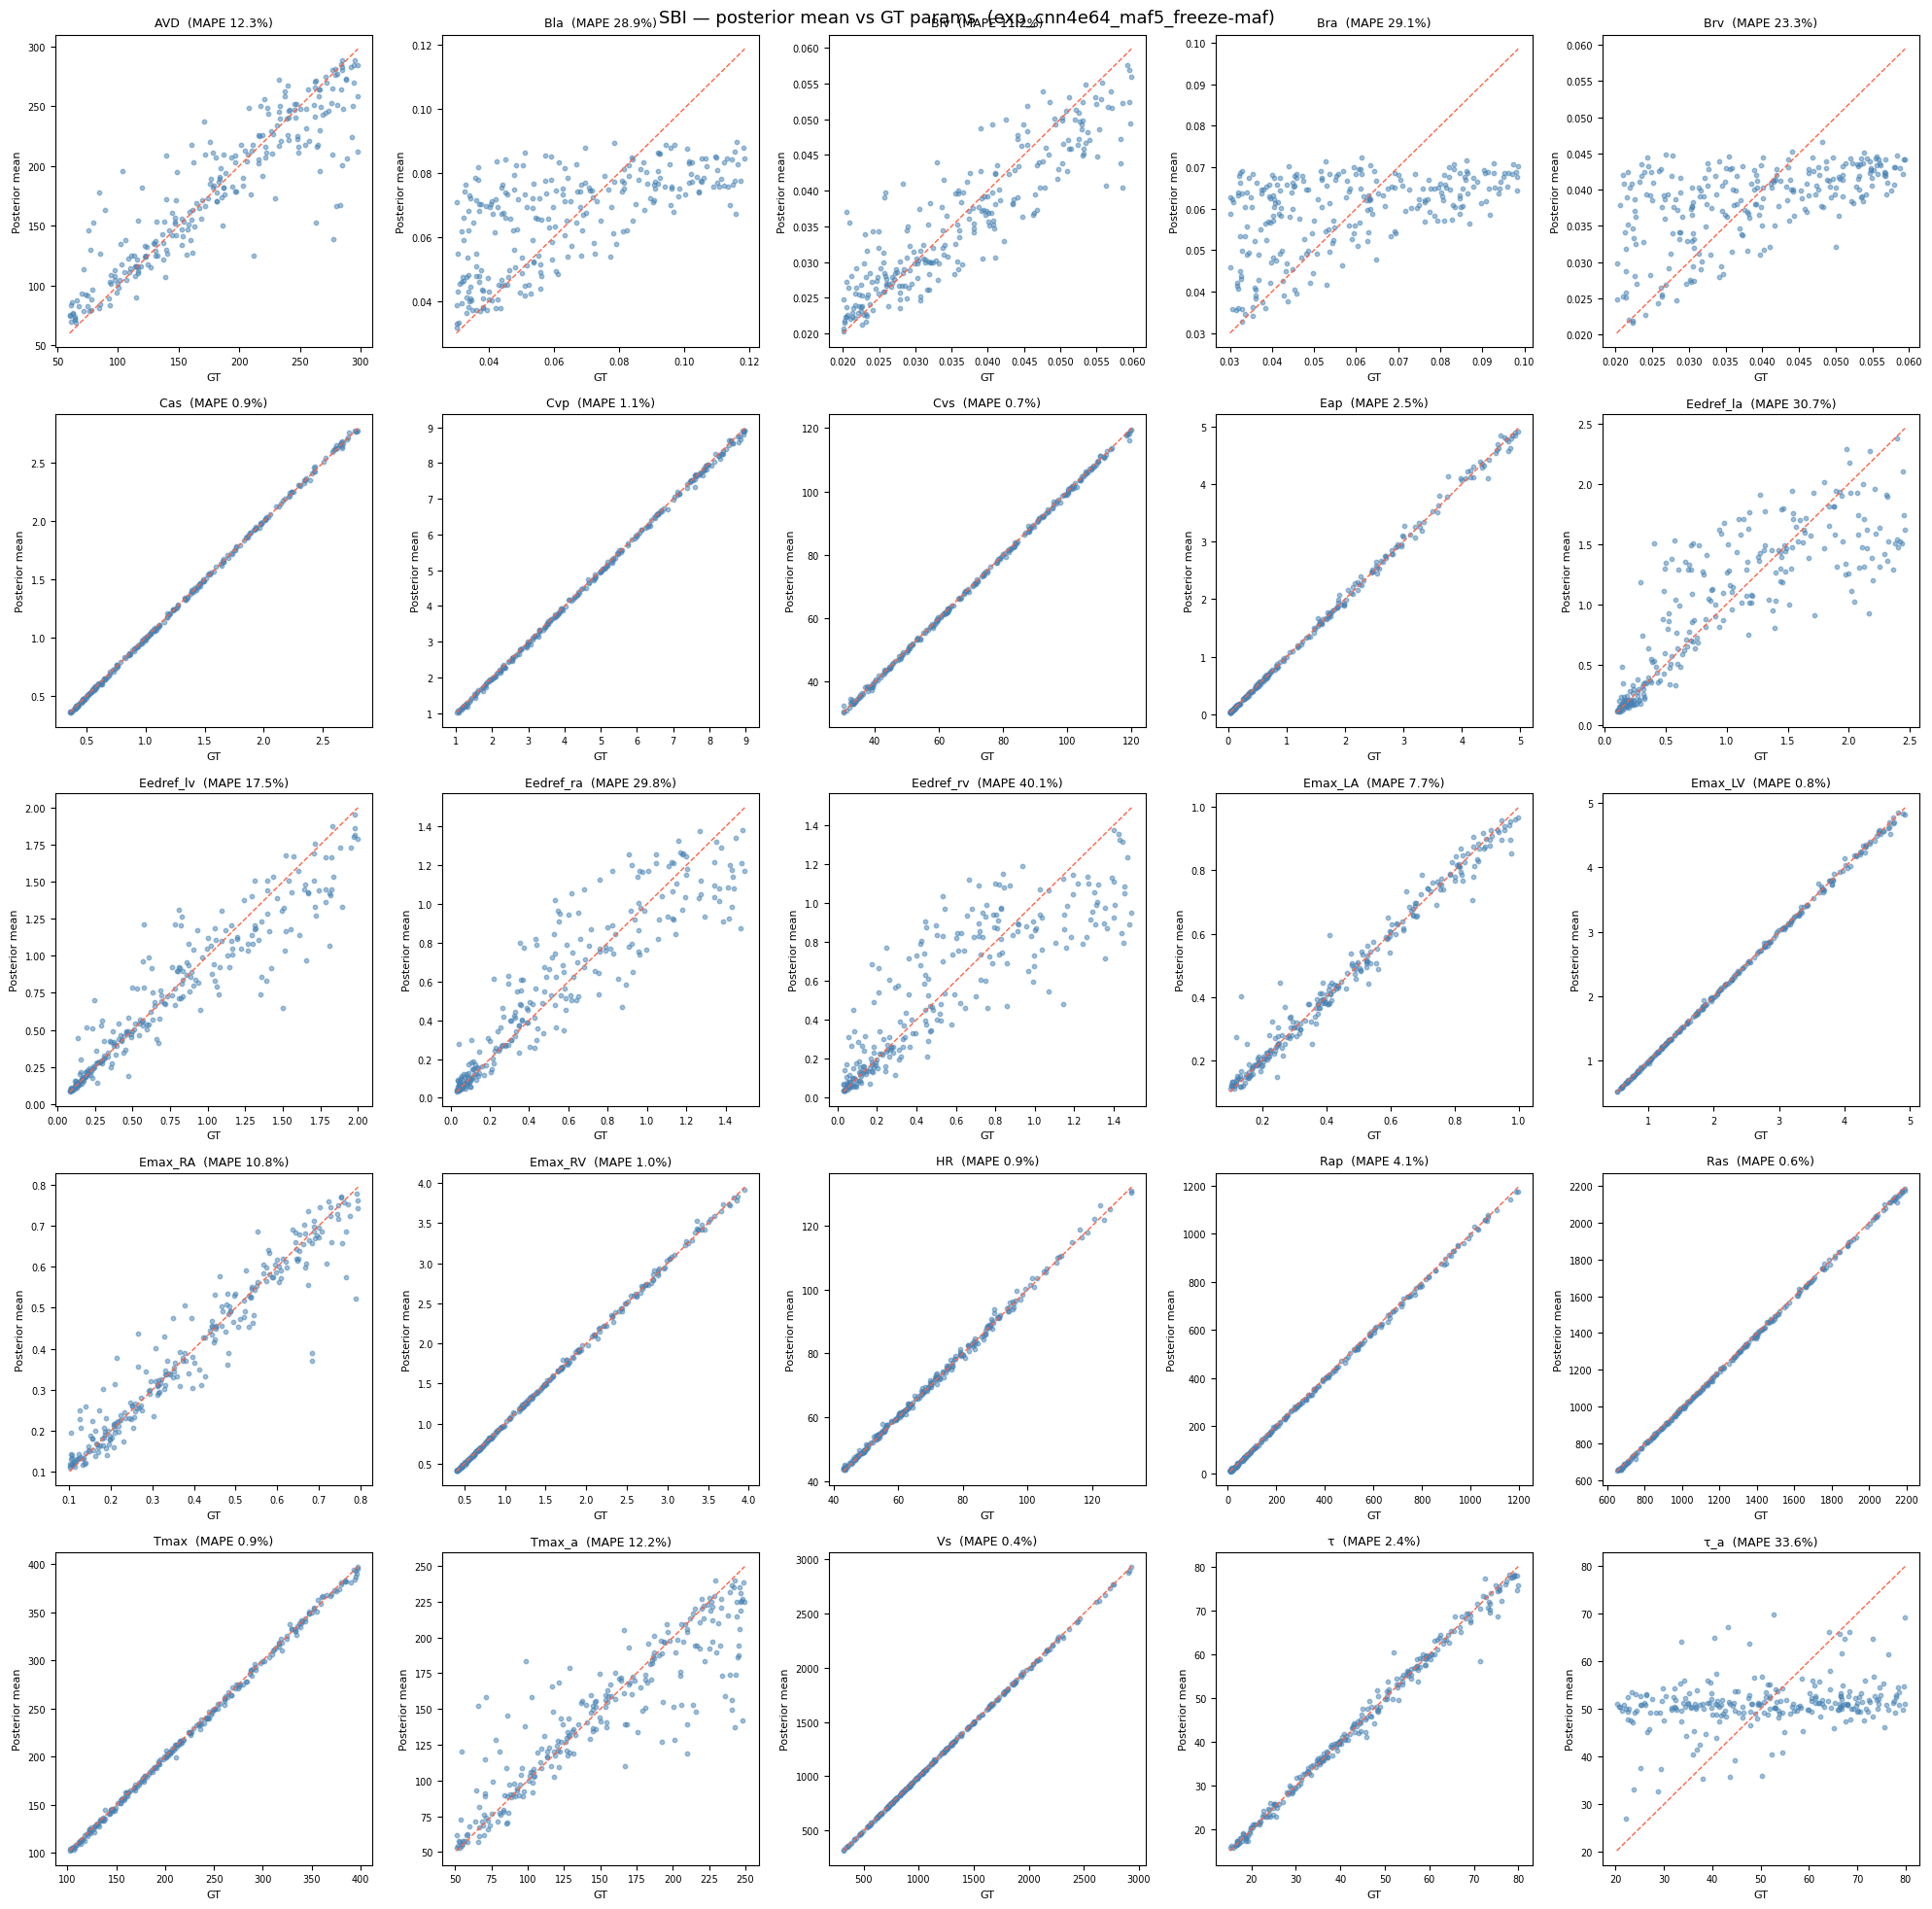

In [38]:
fig, axes = plt.subplots(scatter_nrows, scatter_ncols,
                          figsize=(4 * scatter_ncols, 4 * scatter_nrows))

for i, name in enumerate(PARAM_KEYS_USE):
    ax = axes[i // scatter_ncols, i % scatter_ncols]
    gt_i, pred_i = gt_phys[:, i], pred_mean[:, i]
    lo, hi = gt_i.min(), gt_i.max()
    ax.scatter(gt_i, pred_i, s=10, alpha=0.5, color='steelblue')
    ax.plot([lo, hi], [lo, hi], color='tomato', linewidth=1, linestyle='--')
    ax.set_title(f'{name}  (MAPE {ch_mape[i]:.1f}%)', fontsize=9)
    ax.set_xlabel('GT', fontsize=8)
    ax.set_ylabel('Posterior mean', fontsize=8)
    ax.tick_params(labelsize=7)

for i in range(len(PARAM_KEYS_USE), scatter_nrows * scatter_ncols):
    axes[i // scatter_ncols, i % scatter_ncols].set_visible(False)

fig.suptitle(f'SBI — posterior mean vs GT params  ({RUN_NAME})', fontsize=13)
plt.tight_layout()
plt.show()

## 90% credible interval coverage

For a well-calibrated posterior, ~90% of GT values should fall inside the 90% CI.

In [39]:
in_ci    = (gt_phys >= q05) & (gt_phys <= q95)
coverage = in_ci.mean(axis=0) * 100

print(f"{'Parameter':<14} {'90% CI coverage':>18}")
print('-' * 35)
for i, name in enumerate(PARAM_KEYS_USE):
    flag = '  ✓' if 85 <= coverage[i] <= 95 else '  ←'
    print(f'{name:<14} {coverage[i]:>16.1f}%{flag}')

print(f'\nMean coverage: {coverage.mean():.1f}%  (target: 90%)')

Parameter         90% CI coverage
-----------------------------------
AVD                        84.4%  ←
Bla                        77.0%  ←
Blv                        87.1%  ✓
Bra                        80.5%  ←
Brv                        80.5%  ←
Cas                        93.8%  ✓
Cvp                        93.8%  ✓
Cvs                        94.9%  ✓
Eap                        96.5%  ←
Eedref_la                  77.3%  ←
Eedref_lv                  86.7%  ✓
Eedref_ra                  82.4%  ←
Eedref_rv                  82.0%  ←
Emax_LA                    88.3%  ✓
Emax_LV                    95.7%  ←
Emax_RA                    87.5%  ✓
Emax_RV                    94.1%  ✓
HR                         94.9%  ✓
Rap                        81.2%  ←
Ras                        79.3%  ←
Tmax                       95.7%  ←
Tmax_a                     82.8%  ←
Vs                         99.6%  ←
τ                          89.5%  ✓
τ_a                        80.9%  ←

Mean coverage: 87.5%  (target

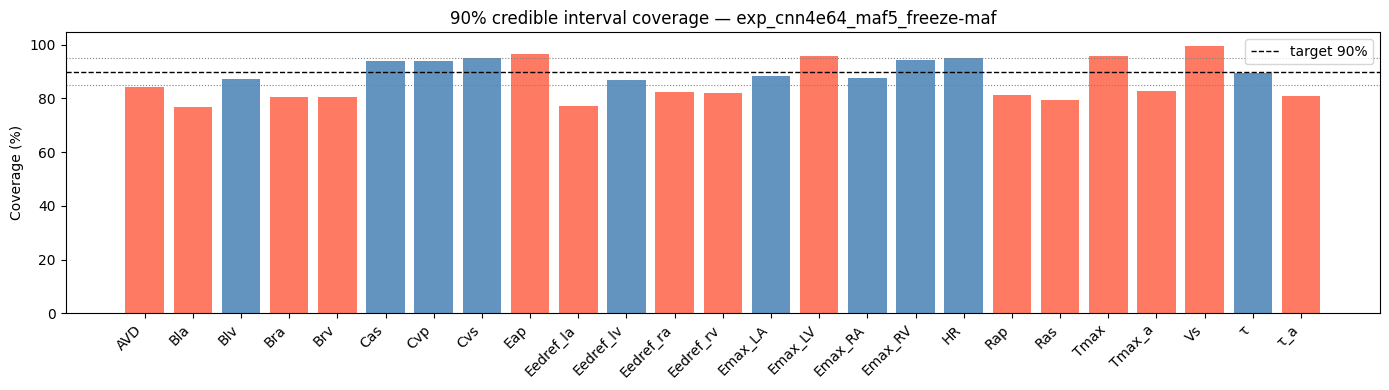

In [40]:
x_pos  = np.arange(len(PARAM_KEYS_USE))
fig, ax = plt.subplots(figsize=(14, 4))
colors  = ['steelblue' if 85 <= c <= 95 else 'tomato' for c in coverage]
ax.bar(x_pos, coverage, color=colors, alpha=0.85)
ax.axhline(90, color='black', linestyle='--', linewidth=1, label='target 90%')
ax.axhline(85, color='gray',  linestyle=':',  linewidth=0.8)
ax.axhline(95, color='gray',  linestyle=':',  linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(PARAM_KEYS_USE, rotation=45, ha='right')
ax.set_ylabel('Coverage (%)')
ax.set_title(f'90% credible interval coverage — {RUN_NAME}')
ax.legend()
plt.tight_layout()
plt.show()